# 2D Deep Learning Models for Impact Echo Classification

This notebook implements the 2D Convolutional Neural Networks (CNNs) evaluated in the 
Dorafshan & Azari (2020) paper. 

Because models like AlexNet were designed for 2D images, the raw 1D Impact Echo signals 
must first be transformed into 2D spectrograms using Short-Time Fourier Transform (STFT). 
The spectrograms are then resized to fit the required input dimensions (e.g., 227x227x3 
for AlexNet) and fed into the network.

## AlexNet (Fully Trained)
* **Architecture:** AlexNet (no pre-trained weights)
* **Input Size:** 227 x 227 x 3
* **Optimizer:** SGDM (Stochastic Gradient Descent with Momentum)
* **Batch Size:** 50
* **Max Epochs:** 40
* **Learning Rate:** 1e-3

In [3]:
import os
import time
import numpy as np
import pandas as pd
from scipy import signal

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision.models as models

from sklearn.metrics import confusion_matrix

# Hardware setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=== Hardware Check ===")
if device.type == 'cuda':
    print(f"SUCCESS: GPU Detected - {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True 
else:
    print("WARNING: CUDA not detected by PyTorch.")
print("======================\n")

c:\Users\kairen.shen.ctr\.conda\envs\bsm\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


=== Hardware Check ===
SUCCESS: GPU Detected - NVIDIA RTX 5000 Ada Generation Laptop GPU



In [4]:
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    
    # Process Defected (Class 1)
    d_folder = os.path.join(slab_folder, "D")
    if os.path.exists(d_folder):
        for file in os.listdir(d_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(d_folder, file))
                all_labels.append(1)
                all_slab_ids.append(slab_id)
                
    # Process Sound (Class 0)
    s_folder = os.path.join(slab_folder, "S")
    if os.path.exists(s_folder):
        for file in os.listdir(s_folder):
            if file.endswith(".txt"):
                all_filepaths.append(os.path.join(s_folder, file))
                all_labels.append(0)
                all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

print(f"Total files found: {len(all_filepaths)}")
print(f"Total Sound (0): {sum(all_labels == 0)}, Total Defected (1): {sum(all_labels == 1)}")

Total files found: 2016
Total Sound (0): 1504, Total Defected (1): 512


## Spectrogram Generator & Dataset
We use `scipy.signal.stft` to generate the frequency-time matrices. 
The magnitudes are converted to a logarithmic scale (dB) for feature contrast.
Using PyTorch's `F.interpolate`, the matrix is resized to 227x227 and duplicated 
across 3 channels to mimic an RGB image format required by AlexNet.

In [5]:
class SpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Load Data & Remove DC Offset
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = voltage - np.mean(voltage)
        
        # 2. Generate Spectrogram via STFT
        f, t, Zxx = signal.stft(voltage, fs=200000, nperseg=128, noverlap=64)
        spec_mag = np.abs(Zxx)
        
        # Convert to log scale (dB) for clearer feature gradients
        spec_log = 10 * np.log10(spec_mag + 1e-8)
        
        # 3. CRITICAL FIX: Zero-Center the spectrogram to [-1, 1]
        # Without Batch Norm, AlexNet ReLUs will die if inputs are exclusively positive [0, 1]
        spec_norm = (spec_log - np.min(spec_log)) / (np.max(spec_log) - np.min(spec_log) + 1e-8)
        spec_norm = (spec_norm - 0.5) / 0.5
        
        # 4. Format to AlexNet specs: (3, 227, 227)
        spec_tensor = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        resized_spec = F.interpolate(spec_tensor, size=(227, 227), mode='bilinear', align_corners=False)
        final_spec = resized_spec.squeeze(0).repeat(3, 1, 1)
        
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return final_spec, label_tensor

def get_alexnet_ft(num_classes=2):
    model = models.alexnet(weights=None)
    model.classifier[6] = nn.Linear(4096, num_classes)
    
    # CRITICAL FIX: Explicit Weight Initialization
    # Because AlexNet lacks BatchNorm, default random weights will trap the SGD optimizer.
    # Kaiming Normal forces the variance to stay stable across the deep convolutions.
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.01)
            nn.init.constant_(m.bias, 0)
            
    return model

In [ ]:
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. Training Protocol (AlexNet FT)
# =========================================================
# Hyperparameters from Table 3 for AlexNet (FT)
EPOCHS = 50 # higher epochs for AlexNet FT to ensure convergence
BATCH_SIZE = 50 # use 50 to check 40 is enough for AlexNet FT to converge
LR = 1e-3
MOMENTUM = 0.9

alexnet_metrics = {'ACC': [], 'TPR': [], 'TNR': [], 'F1': []}
iteration_accuracies = {slab: [] for slab in range(1, 9)}
total_start_time = time.time()

for test_slab in range(1, 9):
    print(f"--- Training AlexNet (FT): Holding out Slab {test_slab} for Testing ---")
    fold_start_time = time.time()
    
    # Split data (Leave-One-Specimen-Out)
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    # Define files and labels to fix the NameError
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = SpectrogramDataset(train_files, train_labels)
    test_dataset = SpectrogramDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = get_alexnet_ft().to(device)
    
    # Dynamic Class Weighting to handle the Sound vs Defected imbalance (~3:1)
    num_sound = np.sum(train_labels == 0)
    num_defected = np.sum(train_labels == 1)
    weight_ratio = num_sound / num_defected
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=5e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            
            # CRITICAL FIX: Gradient clipping ensures SGD doesn't explode the initial weights
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            optimizer.step()
            running_loss += loss.item()
            
            # Calculate and store batch accuracy for the Iteration Plot
            _, preds = torch.max(outputs, 1)
            correct = (preds == targets).sum().item()
            batch_acc = (correct / targets.size(0)) * 100.0  
            iteration_accuracies[test_slab].append(batch_acc)
            
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:02d}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targs = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targs.extend(targets.cpu().numpy())
            
    tn, fp, fn, tp = confusion_matrix(all_targs, all_preds).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0  
    acc = (tp + tn) / (tp + tn + fp + fn)           
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0 
    
    fold_time = time.time() - fold_start_time
    print(f"  > Test Slab {test_slab} Results - ACC: {acc:.2f} | TPR: {tpr:.2f} | TNR: {tnr:.2f} | F1: {f1:.2f}")
    print(f"  > Fold completed in {fold_time:.1f} seconds.\n")
    
    alexnet_metrics['ACC'].append(acc)
    alexnet_metrics['TPR'].append(tpr)
    alexnet_metrics['TNR'].append(tnr)
    alexnet_metrics['F1'].append(f1)

history_path = os.path.join(os.getcwd(), "resnet_tl_iteration_accuracies.pkl")
with open(history_path, "wb") as f:
    pickle.dump(iteration_accuracies, f)
print(f"Saved training history to {history_path}")

total_time = time.time() - total_start_time

# =========================================================
# 2. Output Summary Metrics
# =========================================================
print("=============================================")
print(f"Total AlexNet (FT) Training Time: {total_time/60:.2f} minutes")
print("=== Overall AlexNet (FT) Performance Metrics ===")

for metric, values in alexnet_metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    cov_val = std_val / mean_val if mean_val > 0 else 0.0
    max_val = np.max(values)
    min_val = np.min(values)
    
    print(f"{metric} - Mean: {mean_val:.2f} | COV: {cov_val:.2f} | Max: {max_val:.2f} | Min: {min_val:.2f}")


--- Training AlexNet (FT): Holding out Slab 1 for Testing ---
  Epoch [01/50] - Loss: 0.6930
  Epoch [10/50] - Loss: 0.6868
  Epoch [20/50] - Loss: 0.5113
  Epoch [30/50] - Loss: 0.3537
  Epoch [40/50] - Loss: 0.2885
  Epoch [50/50] - Loss: 0.2759
  > Test Slab 1 Results - ACC: 0.95 | TPR: 0.92 | TNR: 0.96 | F1: 0.91
  > Fold completed in 279.0 seconds.

--- Training AlexNet (FT): Holding out Slab 2 for Testing ---
  Epoch [01/50] - Loss: 0.6928
  Epoch [10/50] - Loss: 0.6789
  Epoch [20/50] - Loss: 0.4343
  Epoch [30/50] - Loss: 0.3226
  Epoch [40/50] - Loss: 0.2679
  Epoch [50/50] - Loss: 0.2669
  > Test Slab 2 Results - ACC: 0.91 | TPR: 0.84 | TNR: 0.94 | F1: 0.83
  > Fold completed in 279.9 seconds.

--- Training AlexNet (FT): Holding out Slab 3 for Testing ---
  Epoch [01/50] - Loss: 0.6935
  Epoch [10/50] - Loss: 0.6878
  Epoch [20/50] - Loss: 0.5194
  Epoch [30/50] - Loss: 0.3778
  Epoch [40/50] - Loss: 0.2992
  Epoch [50/50] - Loss: 0.2626
  > Test Slab 3 Results - ACC: 0.91 | 


Generating Accuracy vs Iteration plot for AlexNet (FT)...


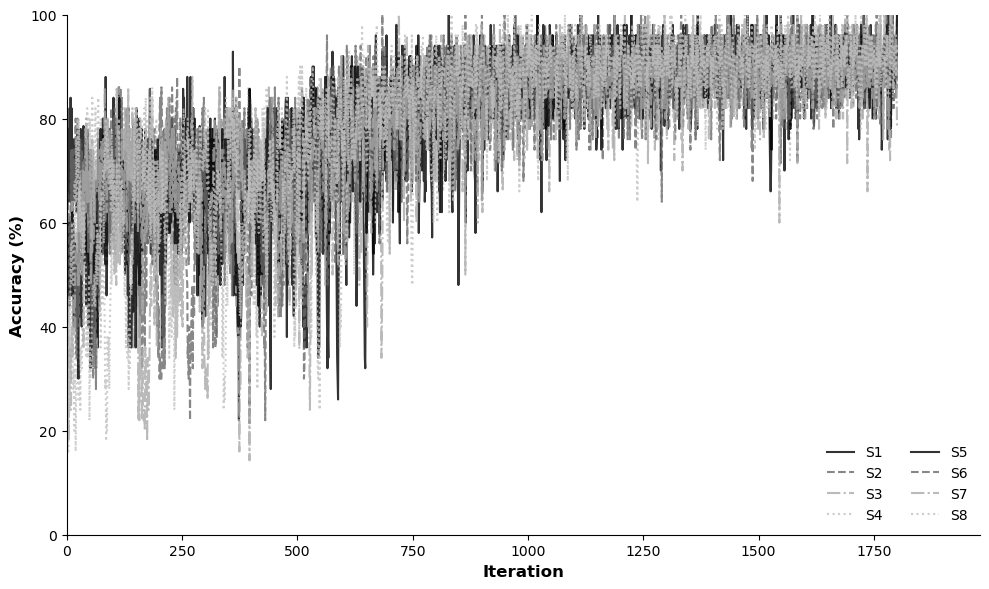

Plot saved successfully as 'alexnet_ft_accuracy_vs_iteration.png'.


In [12]:
# =========================================================
# 3. Plotting Accuracy vs Iteration
# =========================================================

print("\nGenerating Accuracy vs Iteration plot for AlexNet (FT)...")
fig, ax = plt.subplots(figsize=(10, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
colors = ['black', 'dimgray', 'darkgray', 'silver', 'black', 'dimgray', 'darkgray', 'silver']

for slab_id in range(1, 9):
    acc_data = iteration_accuracies[slab_id]
    iterations = range(1, len(acc_data) + 1)
    
    ax.plot(iterations, acc_data, label=f'S{slab_id}', 
             linestyle=line_styles[slab_id-1], color=colors[slab_id-1], alpha=0.8, linewidth=1.5)

ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)

# Add some padding to the x-axis for the legend to breathe
ax.set_xlim(0, len(iteration_accuracies[1]) * 1.1) 

# Clean up axes for a publication-ready look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('alexnet_ft_accuracy_vs_iteration.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved successfully as 'alexnet_ft_accuracy_vs_iteration.png'.")